In [1]:
import sklearn
print(sklearn.__version__)

from sklearn.datasets import load_iris
import pandas as pd

iris_data = load_iris()
X = iris_data.data
y = iris_data.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

1.6.1
X shape: (150, 4)
y shape: (150,)


In [ ]:
## barchar 예제
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.bar(d["Fold"], df_scores["Accuracy"])
plt.ylim(0,1)
plt.title("5-Fold Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

In [2]:
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [120]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X_full, y_full = iris.data, iris.target

# 모델 선정(생성)
clf = DecisionTreeClassifier(random_state=18)
# 모델 학습(fit)
clf.fit(X_full, y_full)

# 예측
pred_full = clf.predict(X_full)

# 정확도 평가
print(f"Accuracy: {accuracy_score(y_full, pred_full):.3f}")

Accuracy: 1.000


## 훈련=평가 착시



위 결과는 대부분 1.000(100%)에 가깝게 나옵니다.
왜냐하면, 나누지 않아서!

## 올바른 평가: train/test split

방법은 간단합니다.
데이터를 두 덩어리로 나눕니다.

- 훈련(train) 데이터: 모델이 공부하는 데이터
- 시험(test) 데이터: 모델이 처음 보는 데이터(시험지)

시험 데이터로 성적을 확인하면, "처음 보는 문제"에서의 진짜 실력을 알 수 있습니다.

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=18

)

# 모델 생성
clf = DecisionTreeClassifier(random_state=18
)
# 훈련 데이터셋으로 학습
clf.fit(X_train, y_train)
# 예측(시험 데이터 셋으로 예측)
y_pred_test = clf.predict(X_test)

# 정확도 평가(시험 데이터셋을 기준으로)
print(f"[train/test split 기준선] Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")

[train/test split 기준선] Accuracy: 0.933


## train/test split

데이터를 훈련(train)과 시험(test)으로 나눠야 하는 이유는 단순합니다.
시험 데이터는 모델이 **처음 보는 문제**이기 때문에, 여기서 나온 점수가 **현실적인 성능**입니다.
→ 시험지를 외우는 게 아니라, 진짜 실력을 보는 과정입니다.

# 04_model_selection — 교차검증(K-Fold)과 모델 선택(GridSearch)

오늘 이 노트북에서 차근차근 할 일

1) 왜 훈련한 데이터로 그대로 평가하면 안 되는지 직접 확인
2) 훈련용과 시험용으로 나누어 평가하는 방법(train/test split)을 배움.
3) 그래도 결과가 흔들릴 수 있어서, 데이터를 여러 번 나눠 평균을 내는 방법(교차검증, K-Fold)을 배움
4) K-Fold를 사람이 일일이 코딩하지 않고, 한 줄로 실행하는 방법(cross_val_score)을 배움
5) 모델의 설정값(하이퍼파라미터)을 바꾸면 결과가 달라진다는 걸 확인하고,
   여러 후보를 공정하게 비교해 최적을 찾는 방법(GridSearchCV)을 배움
6) 마지막으로, 처음 보는 시험지(test set)에서 한 번 더 성능을 확인

---
## Part 2. 교차검증 (Cross-Validation)

**핵심 질문**: Train/Test를 한 번만 나누면 충분할까?

한 번의 분할은 **운**에 좌우될 수 있습니다.
쉬운 샘플만 테스트에 들어가면 성능이 높게, 어려운 샘플이 들어가면 낮게 나옴

### K-Fold 교차검증
1. 전체 훈련 데이터를 **K등분** (K 값은 상황에 따라 달라짐)
2. 매 라운드마다 **1등분을 검증, 나머지 K-1등분을 학습**에 사용
3. K번 반복하여 **모든 데이터가 한 번씩 검증**에 사용됨
4. K개의 점수를 **평균 ± 표준편차**로 보고

> 한 번 나누기: "시험 한 번"으로 실력 판단 → 불안정
> K-Fold: "모의고사 여러 번(K번)"의 평균 → 신뢰할 수 있는 실력 측정

![K-Fold vs Holdout 개념](스크린샷%202026-02-06%20오전%2010.26.49.png)

### K-Fold 직접 구현해보기

아래 그림은 K=5인 경우의 예시로,

데이터를 5등분하여 매번 다른 부분을 검증에 사용함

![5-Fold 교차검증 시각화](스크린샷%202026-02-06%20오전%2010.27.37.png)

In [147]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

# 코드 볼 필요 없음

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

fold_scores = []
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    model = DecisionTreeClassifier(random_state=18
)
    model.fit(X[train_idx], y[train_idx])
    score = accuracy_score(y[test_idx], model.predict(X[test_idx]))
    fold_scores.append((fold, score))

df_scores = pd.DataFrame(fold_scores, columns=["Fold", "Accuracy"])
df_scores
print(f"평균={df_scores['Accuracy'].mean():.3f}, 표준편차={df_scores['Accuracy'].std():.3f}")

평균=0.947, 표준편차=0.051


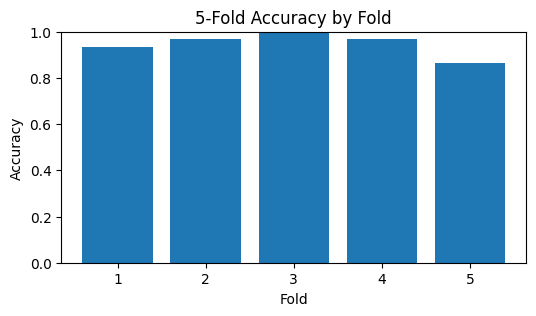

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.bar(df_scores["Fold"], df_scores["Accuracy"])
plt.ylim(0,1)
plt.title("5-Fold Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

- 방금은 교차검증의 "원리"를 직접 코드로 실행해 본 것임
- 한 번만 나눠서 나온 성적이 아니라, 여러 번 나눠 평균냈기 때문에 더 믿을 수 있음


- 하지만 이렇게 매번 for문을 돌리는 것은 귀찮


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=18

)

## cross_val_score로 간단히 교차검증

위 과정을 scikit-learn이 자동으로 해줌
평균 성적과 표준편차를 바로 얻을 수 있음

In [ ]:


        from sklearn.model_selection import cross_val_score

        # DecisionTree에 5-Fold 교차검증 적용
        dt = DecisionTreeClassifier(random_state=18)
        scores = cross_val_score(dt,
                                X_train,
                                y_train,
                                cv=4,
                                scoring="accuracy")


        print(f"각 Fold 정확도: {scores.round(3)}")
        print(f"평균 정확도:    {scores.mean():.3f} ± {scores.std():.3f}")
        print()



각 Fold 정확도: [0.944 1.    0.882 1.    0.941 1.    0.941]
평균 정확도:    0.958 ± 0.041



In [ ]:


        from sklearn.linear_model import LogisticRegression
        from sklearn.neighbors import KNeighborsClassifier

        # 여러 모델을 교차검증으로 공정하게 비교
        models = {
            "DecisionTree": DecisionTreeClassifier(random_state=18, max_depth=5
        ),
            "LogisticRegression": LogisticRegression(max_iter=2000, random_state=18
        ),
            "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        }

        print(f"{'모델':<25s}  {'평균 정확도':>8s}  {'표준편차':>6s}")
        print("-" * 50)
        for name, model in models.items():
            scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
            print(f"{name:<25s}  {scores.mean():>8.3f}  ±{scores.std():.3f}")

            

모델                           평균 정확도    표준편차
--------------------------------------------------
DecisionTree                  0.942  ±0.042
LogisticRegression            0.967  ±0.049
KNN (k=5)                     0.975  ±0.033


### CV mean과 CV std를 함께 봐야 하는 이유

교차검증 결과는 항상 이렇게 나옵니다:
```
CV mean = 0.90
CV std  = 0.08
```

이 숫자의 의미는 단순히 "평균이 높다"가 아님

| 지표 | 의미 |
|------|------|
| **mean** | 전반적인 성능 수준 |
| **std** | 데이터 분할에 따른 성능 흔들림 |

**std가 크다는 건:**
- 어떤 fold에서는 잘하고
- 어떤 fold에서는 갑자기 못한다는 뜻
- 데이터 분할에 민감하게 반응하는 모델이라는 뜻
- -> **불안정한 모델의 신호**일 수도 있고
- -> 데이터에 특정 구조나 순서, 민감한 패턴이 있다는 신호일 수도 있음
- -> 데이터 자체 불균형


실무에서는 데이터 분포가 항상 바뀌기 때문에,
**"지금 데이터에서 잘 맞는 모델"**보다
**"데이터가 바뀌어도 덜 흔들리는 모델"**이 살아남음


In [181]:
# 같은 모델이라도 random_state에 따라 결과가 달라지는 것을 확인
import numpy as np

np.random.seed(18)
random_states = np.random.randint(0, 100, size=5)

for rs in random_states:
    dt_temp = DecisionTreeClassifier(random_state=rs)
    scores = cross_val_score(dt_temp, X_train, y_train, cv=5, scoring="accuracy")
    print(f"random_state={rs:3d}  →  평균={scores.mean():.3f}, std={scores.std():.3f}")

print("\n→ random_state만 바꿔도 성능이 달라짐!")

random_state= 42  →  평균=0.942, std=0.042
random_state= 19  →  평균=0.950, std=0.031
random_state= 69  →  평균=0.942, std=0.042
random_state= 62  →  평균=0.942, std=0.042
random_state= 49  →  평균=0.950, std=0.031

→ random_state만 바꿔도 성능이 달라짐!


> **표준편차가 작을수록 안정적**임
> 평균이 비슷하다면, 표준편차가 작은 모델이 더 믿을 만할 수 있음

### 모델 선택(가이드(법칙은 아님))


실무에서 모델을 선택할 때 사용하는 기준입

| 우선순위 | 기준 | 설명                  |
|:--------:|------|---------------------|
| 1 | **CV mean이 높을수록 좋다** | 기본적인 성능             |
| 2 | **CV std가 작을수록 중요하다** | 안정성 (더 주의 깊게 봐야 함!) |
| 3 | **mean 차이가 1~2%p라면** → std가 작은 모델 선택 | 비슷한 성능이면 안정성 우선     |

**왜 std도 고려해야하는가?**

실무에서는 데이터 분포가 항상 바뀝니다.
- 오늘 들어온 고객 데이터 ≠ 내일 들어올 고객 데이터
- 이번 달 매출 패턴 ≠ 다음 달 매출 패턴

**"지금 데이터에서 잘 맞는 모델"**보다
**"데이터가 바뀌어도 덜 흔들리는 모델"**이 살아남음

In [10]:
model_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model_results.append({
        "모델": name,
        "CV mean": scores.mean(),
        "CV std": scores.std(),
    })

df_compare = (
    pd.DataFrame(model_results)
      .sort_values(["CV mean", "CV std"], ascending=[False, True])
      .reset_index(drop=True)
)

df_compare


print("-" * 50)

top_n = min(3, len(df_compare))
for i in range(top_n):
    row = df_compare.iloc[i]
    print(f"• {row['모델']}: mean={row['CV mean']:.3f} ({i+1}위), std={row['CV std']:.3f}")

print("\상위 2개 모델 중 어떤 걸 선택할까?\n")

if len(df_compare) >= 2:
    top1 = df_compare.iloc[0]
    top2 = df_compare.iloc[1]

    mean_diff = top1["CV mean"] - top2["CV mean"]
    mean_diff_pp = mean_diff * 100  # 퍼센트포인트(%p)로 변환

    threshold_pp = 1.0  # mean 차이가 1.0%p 이하면 "비슷"하다고 보고 std를 더 고려

    if mean_diff_pp <= threshold_pp:
        # mean이 비슷하면 std가 더 작은 모델을 안정적인 선택으로 봄
        chosen = top1 if top1["CV std"] <= top2["CV std"] else top2
        print(f"→ 선택: {chosen['모델']}")
        print(f"→ 근거: mean 차이가 {mean_diff_pp:.1f}%p로 크지 않아서(≤ {threshold_pp:.1f}%p), std가 더 작은 모델을 우선순위\n")
    else:
        # mean 차이가 확실히 크면 mean이 높은 모델을 우선
        chosen = top1
        print(f"→ 선택: {chosen['모델']}")
        print(f"→ 근거: mean 차이가 {mean_diff_pp:.1f}%p로 꽤 커서(> {threshold_pp:.1f}%p), mean이 높은 모델을 우선순위\n")


--------------------------------------------------
• KNN (k=5): mean=0.975 (1위), std=0.033
• LogisticRegression: mean=0.967 (2위), std=0.049
• DecisionTree: mean=0.942 (3위), std=0.042
\상위 2개 모델 중 어떤 걸 선택할까?

→ 선택: KNN (k=5)
→ 근거: mean 차이가 0.8%p로 크지 않아서(≤ 1.0%p), std가 더 작은 모델을 우선순위



---
## Part 3. GridSearchCV — 하이퍼파라미터 자동 탐색

**하이퍼파라미터** = 사람이 직접 정해줘야 하는 설정값

예: DecisionTree의 `max_depth` (트리의 최대 깊이)
- 너무 크면 → **과적합** (훈련 데이터를 외움)
- 너무 작으면 → **과소적합** (패턴을 충분히 못 배움)

**GridSearchCV**: 후보값을 모두 넣으면, 교차검증으로 가장 좋은 조합을 **자동**으로 찾아줍니다.


![GridSearchCV 기본 메커니즘](스크린샷%202026-02-06%20오전%2011.43.44.png)

### 하이퍼파라미터가 성능에 미치는 영향: max_depth

- **언더피팅**: 트리 깊이가 너무 얕음 → 모델이 너무 단순해서 패턴을 못 배움
- **오버피팅**: 트리 깊이가 너무 깊음 → 훈련 데이터만 외움
- 적당한 깊이가 필요합니다 → 균형 잡힌 공부 습관!

In [ ]:




            import pandas as pd

            from sklearn.tree import DecisionTreeClassifier
            from sklearn.model_selection import train_test_split
            from sklearn.model_selection import cross_val_score
            from sklearn.metrics import accuracy_score

            from sklearn.datasets import load_iris

            iris = load_iris()
            X_full, y_full = iris.data, iris.target

            X_train, X_test, y_train, y_test = train_test_split(
                X_full, y_full, test_size=0.2, stratify=y_full, random_state=18

            )

            # depth 후보 리스트 정의 (None = 트리가 끝까지 자람)
            depth_candidates = [2, 3, 4, None]
            rows = []

            for d in depth_candidates:
                scores = cross_val_score(
                    DecisionTreeClassifier(max_depth=d, random_state=18),
                    X_train, y_train, cv=5, scoring="accuracy"
                )
                rows.append((d, scores.mean(), scores.std()))

            df_depth = pd.DataFrame(rows, columns=["max_depth", "cv_mean_acc", "cv_std"]) \
                .sort_values("cv_mean_acc", ascending=False) \
                .reset_index(drop=True)
            df_depth

            

,max_depth,cv_mean_acc,cv_std
0,2.0,0.950000,0.048591
1,3.0,0.941667,0.042492
2,4.0,0.941667,0.042492
3,NaN,0.941667,0.042492


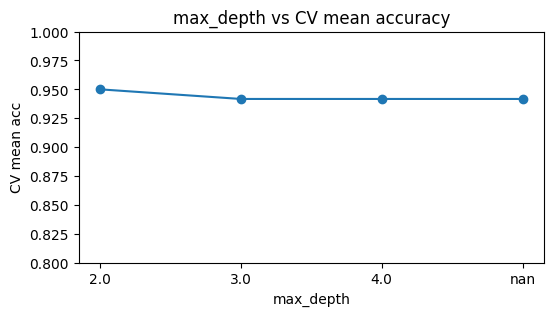

In [12]:
# 깊이 vs 성능 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
x = [str(d) for d in df_depth["max_depth"]]
plt.plot(x, df_depth["cv_mean_acc"], marker="o")
plt.ylim(0.8, 1)
plt.title("max_depth vs CV mean accuracy")
plt.xlabel("max_depth")
plt.ylabel("CV mean acc")
plt.show()

### GridSearchCV 사용하기

- 여러 파라미터 후보(예: max_depth, min_samples_split)를 지정합니다.
- GridSearchCV는 내부적으로 교차검증을 사용하여 각 조합의 평균 성적을 계산합니다.
- 가장 좋은 조합(best_params_)과 그때의 성적(best_score_)을 알려줍니다.

In [182]:
from sklearn.model_selection import GridSearchCV

# 탐색할 하이퍼파라미터 후보
param_grid = {
    "max_depth": [2, 3, 4, None],
}

# GridSearchCV: 4개 후보 × 5-Fold = 총 20번 학습
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=18
),
    param_grid,
    cv=5,
    scoring="accuracy",
    # return_train_score=True   # 훈련 점수도 확인 (과적합 점검용)
)
grid.fit(X_train, y_train)

print(f"최적 파라미터: {grid.best_params_}")
print(f"최적 교차검증 정확도: {grid.best_score_:.3f}")

최적 파라미터: {'max_depth': 2}
최적 교차검증 정확도: 0.950


In [14]:
# 모든 후보의 결과를 표로 정리
cv_df = pd.DataFrame(grid.cv_results_)[
    ["param_max_depth", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
].rename(columns={
    "param_max_depth": "max_depth",
    "mean_train_score": "훈련 정확도",
    "mean_test_score": "검증 정확도",
    "std_test_score": "표준편차",
    "rank_test_score": "순위",
}).sort_values("순위")

cv_df
print()
print("→ 훈련 정확도와 검증 정확도의 차이가 크면 과적합 의심!")


→ 훈련 정확도와 검증 정확도의 차이가 크면 과적합 의심!


###  초심자가 빠지기 쉬운 GridSearchCV 오해

> **"GridSearchCV = 다 넣어보면 알아서 정답 찾아주는 마법 상자?"**

이 생각은 **가장 위험한 습관**!

**GridSearchCV는 '자동 설계자'가 아니라 '자동 실험기'**

| GridSearchCV가 하지 않는 것 | GridSearchCV가 하는 것 |
|:---:|:---:|
| 수학적 원리 이해 | 내가 후보로 준 값들끼리만 비교 |
| 최적 값 자동 탐색 | 교차검증으로 공정하게 평가 |

**설계를 잘못하면 "정성스럽게 틀린 답"을 얻습니다.** - 헛수고
- GridSearchCV는 '설계자'가 아니라 '탐색기'
- 이 도구는 모델을 이해하거나 파라미터의 의미를 판단하지 않음
- 오직 당신이 설계한 후보군 안에서만 비교를 수행

> **후보 범위를 잘못 잡으면, 아무리 오래 돌려도 좋은 모델을 찾을 수 없음.**


![설계 흐름: EDA → 가설 → GridSearch](스크린샷%202026-02-06%20오전%2011.47.12.png)



> **사람의 설계가 먼저, GridSearch는 그 다음.**

---
## Part 4. 최종 홀드아웃 평가

교차검증으로 좋은 조합을 찾았어도, 마지막에는 **처음 보는 시험지(test set)**에서 성능을 한 번 더 확인해야 함!
이 단계가 있어야 "실제로 배포했을 때도 잘 동작할 가능성이 높다"고 말할 수 있음

> 모의고사(K-Fold)에서 우수 모델을 뽑았으니, 이제 **남겨둔 진짜 시험지(test set)**로 성적을 확인!

### 데이터의 역할 분담

![Train/Validation/Test 데이터 역할 분담](스크린샷%202026-02-06%20오전%2010.28.07.png)

In [15]:
# 최종 평가: GridSearchCV가 찾은 최적 모델로 홀드아웃 테스트
best_model = grid.best_estimator_
pred_final = best_model.predict(X_test)
final_acc = accuracy_score(y_test, pred_final)

print(f"최적 모델: DecisionTree(max_depth={grid.best_params_['max_depth']})")
print(f"교차검증 정확도:       {grid.best_score_:.3f}")
print(f"홀드아웃 테스트 정확도: {final_acc:.3f}")
print()
print("→ 두 점수가 비슷하면 모델이 안정적!")

최적 모델: DecisionTree(max_depth=2)
교차검증 정확도:       0.950
홀드아웃 테스트 정확도: 0.900

→ 두 점수가 비슷하면 모델이 안정적!


> **전체 흐름 정리:**
> 1. `train_test_split`으로 홀드아웃 테스트셋을 떼어둠
> 2. 훈련 데이터에서 `cross_val_score`로 모델 비교
> 3. `GridSearchCV`로 최적 하이퍼파라미터 탐색
> 4. 최종 모델을 **한 번도 보지 않은 테스트셋**으로 평가
>
> 테스트셋은 **마지막에 딱 한 번만** 사용합니다!

### 💡 2회차에서 가져가야 할 핵심 메시지

| 순서 | 내용 |
|:----:|------|
| 1 | 모델은 **한 번의 점수**로 평가하지 않는다 |
| 2 | 모델 선택은 **평균 + 안정성**의 문제다 |
| 3 | **교차검증**은 모델 선택을 위한 도구 |
| 4 | **최종 성능**은 holdout test에서 **한 번만** 확인 |

이 구조를 이해하면, 이후 회차에서 어떤 모델을 배우든
**항상 같은 평가 기준**을 적용할 수 있습니다.

> **2회차 핵심 문장:**
> "좋은 모델은 점수가 높은 모델이 아니라, **점수가 덜 흔들리는 모델**이다."

---
## 오늘의 정리

| 개념 | 핵심 | 코드 |
|------|------|------|
| Train/Test Split | 처음 보는 데이터로 평가해야 진짜 실력 | `train_test_split(X, y)` |
| 교차검증 (K-Fold) | 한 번 나누기는 운에 좌우 → K번 나눠서 평균 | `cross_val_score(model, X, y, cv=5)` |
| GridSearchCV | 하이퍼파라미터 후보를 교차검증으로 공정 비교 | `GridSearchCV(model, param_grid, cv=5)` |
| 과적합 점검 | 훈련 점수 ↑↑ 검증 점수 ↓ → 외운 것 | train/test 점수 차이 확인 |

> **기억할 흐름**: EDA → Train/Test 분리 → 교차검증 → GridSearch 튜닝 → 홀드아웃 최종 평가

---
## 2회차 정리

**2회차의 핵심은 "모델을 만드는 것"이 아니라, "모델을 고르는 기준을 배우는 것"**

### 흔한 착각
> "정확도가 높은 모델 = 좋은 모델"

이 생각은 **위험**함. 2회차는 이 착각을 의도적으로 깨는 회차

### 왜 위험한가?

1. **Holdout 평가의 한계**
   - 데이터를 어떻게 나누느냐에 따라 점수가 달라질 수 있다
   - 한 번의 test 결과는 우연일 수 있다
   - 이 점수로 모델을 선택하면 불안정한 선택이 될 수 있다

2. **자연스러운 질문**
   > "이 모델 점수... 믿어도 되는 걸까?"

3. **그래서 등장하는 게 교차검증(Cross Validation)**
   - 한 번 나눈 test 점수 대신, **여러 번 나눠서 평균**을 봄
   - **평균(mean)**과 **표준편차(std)**로 모델을 평가한다

### 2회차 핵심 문장

> **"좋은 모델은 점수가 높은 모델이 아니라,
여러 번 평가해도 점수가 덜 흔들리는 모델이다."**

---
## 실습 미션

### 미션 1: DecisionTree max_depth 실험
DecisionTree에서 `max_depth`를 2, 3, None으로 각각 바꿔 실행하세요.
- 정확도를 기록하고, 어떤 깊이가 가장 좋은지 한 줄 코멘트 작성

### 미션 2: KNN n_neighbors 실험
KNN에서 `n_neighbors`를 3, 5, 9로 각각 실행하세요.
- 정확도를 기록하고, 어떤 k가 가장 좋은지 한 줄 코멘트 작성

### 미션 3: 결과 정리
아래 표에 결과를 정리하세요. (빈칸 채우기)

| model        | param          | accuracy | 코멘트 |
|--------------|----------------|----------|---------|
| DecisionTree | max_depth=2    |          |         |
| DecisionTree | max_depth=3    |          |         |
| DecisionTree | max_depth=None |          |         |
| KNN          | n_neighbors=3  |          |         |
| KNN          | n_neighbors=5  |          |         |
| KNN          | n_neighbors=9  |          |         |

### 미션 4: GridSearchCV 확장 (도전)
GridSearchCV 파라미터에 `min_samples_split=[2,4,8]`를 추가하세요.
- 다시 실행한 후 상위 5개 결과를 표로 정리하세요.

In [16]:
# 미션 1 풀이 공간


In [17]:
# 미션 2 풀이 공간


In [18]:
# 미션 4 풀이 공간 (도전)


---
## 다음 시간 예고

- **전처리 (Preprocessing)**: 스케일링, 인코딩 — 모델 성능의 기초
- **Pipeline**: 전처리 + 모델을 한 줄로 묶어 실수 방지
- **분류 평가지표 심화**: Confusion Matrix, Precision, Recall, F1-Score

> 오늘 모델을 학습하고 튜닝하는 흐름을 익혔으니,
> 다음엔 **데이터를 모델에 맞게 준비하는 방법**을 배웁니다.